<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/G5_EGG_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [328]:
import sklearn
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.model_selection import GridSearchCV
import joblib


In [4]:
drive.flush_and_unmount()
drive.mount('/content/drive')
dataset_path="/content/drive/MyDrive/Healthcare/EGG"
os.chdir(dataset_path)

Mounted at /content/drive


In [5]:
df = pd.read_excel('EEG-data.xlsx')

In [7]:
df.head(10)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,0,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,1,14,25,31,36,33,33,27,27,21,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,2,-159,-176,-174,-145,-101,-45,0,29,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,3,34,31,29,19,16,12,3,-1,-5,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,4,44,50,46,43,43,46,45,40,36,...,4,5,6,6,2,1,0,-1,-4,2
5,5,142,262,382,451,452,435,544,562,462,...,164,-2,-118,-223,-304,-350,-339,-299,-253,1
6,6,-64,-72,-52,-24,4,21,18,-16,-53,...,-90,-85,-66,-42,-26,-10,-1,-12,-16,5
7,7,-55,-48,-48,-38,-23,0,11,22,21,...,51,61,64,42,-1,-53,-79,-93,-95,4
8,8,18,14,13,9,-6,-20,-31,-27,-10,...,-17,-3,9,25,49,63,82,96,102,4
9,9,50,48,45,41,47,51,53,40,37,...,-16,-30,-47,-63,-63,-50,-39,-25,-19,3


## Building and training an optimize model

In [251]:

def plot_confusion_matrix(confusion_matrix=None):
  """
  Plot confusion matrix in horizontal format.
  Works with:
  - A single 2D numpy array
  - A dictionary of multiple confusion matrices (e.g., from multiple models)
  """
  if isinstance(confusion_matrix, np.ndarray):
    confusion_matrix = {'Model': [confusion_matrix]}

  fig, axes = plt.subplots(1, len(confusion_matrix), figsize=(12,3))

  if len(confusion_matrix) == 1:
    axes = [axes] # <-- Make sure axes is iterable if 1D array passed

  for ax, (name, matrices) in zip(axes, confusion_matrix.items()):

      avg_cm = np.mean(matrices, axis=0)

      ax.imshow(avg_cm)
      ax.set_title(name)
      ax.set_xlabel("Predicted")
      ax.set_ylabel("Actual")

      for i in range(matrices[0].shape[0]):
          for j in range(matrices[0].shape[0]):
              ax.text(j, i, round(avg_cm[i,j],1), ha="center")

  plt.tight_layout()
  plt.show()

In [198]:
def outliers_middleware(threshold=None, include_outlier=False):
  if include_outlier == False and (threshold is None or threshold <= 0):
    raise ValueError("threshold must be greater than 0")

In [322]:
def prepare_dataset(dataset, threshold=None, include_outlier=False):
  """
  Clean up the dataset for the features and attributes & normalize the dataset using z-transform
  """
  outliers_middleware(threshold, include_outlier) # handling threshold error
  feature_columns = dataset.columns.drop(['Unnamed: 0','y'], errors='ignore')
  X = dataset[feature_columns]
  mean = np.mean(X)
  std = np.std(X)
  X = (X-mean)/std # <-- z-transform normalization
  y = dataset.get('y') if 'y' in dataset.columns else dataset.get('Y')

  # Remove outliers
  if not include_outlier:
    mask = np.all((X<threshold) & (X>-threshold), axis=1)
    X_clean = X[mask]
    y_clean = y[mask]
    return X_clean, y_clean
  else:
    return X, y, mean, std, feature_columns

In [323]:
def validate_model(model=None, X_test=None, y_test=None):
  """
  This method validate the modeld and return
  - `accuracy, y_pred, y_prob, cm`
  """
  y_pred = model.predict(X_test)
  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)
  else:
      y_prob = None
  # 2. 3 → accuracy1
  accuracy = np.sum(y_pred == y_test)/len(y_test)
  cm = confusion_matrix(y_test, y_pred)
  return accuracy, y_pred, y_prob, cm

In [324]:
# training multy layer classier
def train_classifier_model(iteration=5, X_train=None, X_test=None, y_train=None, y_test=None, models=None):
  """
  Training multi model classifier
  Returns:
        accuracy: dict of accuracy for each model on `X_test` & `y_test`
        final_trained_models: dict of models trained on  `X_train` & `y_train`
        con_matrix: dic of confusion matrix for each model `X_test` & `y_test`
  """
  accuracy_items = {name: [] for name in models }
  trained_model = {name: None for name in models }
  con_matrix = {name: [] for name in models }

  # Training iteration
  for ntimes in range(iteration):
     # 2.1 Train SVM on first half
    for name, model in models.items():

      model.fit(X_train, y_train)
      # validate model on test dataset
      accuracy, y_pred, _, cm = validate_model(model, X_test, y_test)

      # 5. Append accuracy to accuracy_items
      accuracy_items[name].append(accuracy)
      trained_model[name] = model
      con_matrix[name].append(cm)
  return accuracy_items, trained_model, con_matrix

In [325]:
def cross_validation_classifier(X=None, y=None, n_splits=1, models=None, param_grids=None):
  """
  Perform k-fold cross-validation on multiple models.

    Returns:
        cv_results: dict of cross validation result for each model
        final_trained_models: dict of models trained on full `X` & `y`
        accuracy: dict of accuracy for each model on full `X` & `y`
        con_matrix: dic of confusion matrix for each model on full `X` & `y`
  - GridSearchCV =  `(number of models) × (number of hyperparameter combinations) × (number of folds)`
  `n_splits & param_grids` can make training process very slow
  """

  final_trained_models = {}
  cv_results = {}

  for name, model in models.items():
      grid = GridSearchCV(
          estimator=model,
          param_grid=param_grids[name],
          cv=n_splits,   # <-- KFold internally
          scoring='accuracy'
      )

      grid.fit(X, y)

      final_trained_models[name] = grid.best_estimator_
      cv_results[name] = grid.cv_results_


  # Validation
  accuracy_items = {}
  con_matrix = {}
  # 1. accuracy --> only best accuracy
  for name in cv_results:
      best_idx = np.argmax(cv_results[name]['mean_test_score'])
      best_acc = cv_results[name]['mean_test_score'][best_idx]
      accuracy_items[name] = [best_acc]
  # 2. confusion matrix
  for name, model in final_trained_models.items():
      y_pred = model.predict(X)
      cm = confusion_matrix(y, y_pred)
      con_matrix[name] = [cm]

  return cv_results, final_trained_models, accuracy_items, con_matrix

In [326]:
# Create the model accuracy table
def create_accuracy_table (accuracy=None, iteration = 1, random_state = None, include_outlier = False, threshold = None):
  table = []
  for name, accuracy_result in accuracy.items():
    means = np.mean(accuracy_result)
    stds = np.std(accuracy_result)
    table.append([name, means, stds, iteration, random_state, include_outlier, threshold])
  table = pd.DataFrame(table, columns=['kernal', 'mean', 'std', 'iteration', 'seed','include_outlier', 'threshold'])
  return table

In [331]:
# Train SVM models for dataset including outliers
def classifier_models(iteration = 1, random_state = None, include_outlier = False, threshold = None, param_grids = None):
  """
  This function will create `4 classifier model`:
  - prepare the feature and classifier attributes
  - prepare the training & testing dataset
  * if `include_outlier = True` the threshold will not applied
  * if `iclude_outlier = False` then threshold must be provided
  - return an accuracy table on each iteration, and trained models for forther validation
  """
  outliers_middleware(threshold, include_outlier) # handling threshold error

  # list of the models to perform
  models = {
        'svm_lin': SVC(kernel='linear', C=1.0, random_state=random_state, decision_function_shape='ovo', probability=True),
        'svm_rbf': SVC(kernel='rbf', C=1.0, random_state=random_state, decision_function_shape='ovo'),
        'tree': DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=random_state),
        'knn': KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    }
  # Prepare the dataset
  X_clean, y_clean, mean, std, feature_columns = prepare_dataset(df, threshold=threshold, include_outlier=include_outlier)

  # Train the classifier model on cross validation
  if param_grids:
    cv_results, trained_models, accuracy, cm = cross_validation_classifier(X_clean, y_clean,
                                                                           n_splits=iteration,
                                                                           models=models,
                                                                           param_grids = param_grids)


    # Create accuracy table for Cross validation accuracy
    table = create_accuracy_table(accuracy=accuracy, iteration=iteration,
                                  random_state=random_state,
                                  include_outlier=include_outlier,
                                  threshold=threshold)
    return accuracy, trained_models, table, cm, mean, std, feature_columns

  else:
    # Get the training and testing dataset
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean,
                                                          test_size=0.2,
                                                          random_state=random_state,
                                                          shuffle=True)

    # train the classifier model
    accuracy, trained_models, cm = train_classifier_model(iteration, X_train, X_test, y_train, y_test, models)


    # create accuracy table
    table = create_accuracy_table(accuracy=accuracy, iteration=iteration,
                                  random_state=random_state,
                                  include_outlier=include_outlier,
                                  threshold=threshold)
    return accuracy, trained_models, table, cm, mean, std, feature_columns

## Grid Search Cross Validation models

**Calssify models iteration**
- grid param
- Include outliers or not
- Iteration
- Seed
- Threshold

In [333]:

param_grids = {
    'svm_lin': {'C':[0.1,1,10]},
    'svm_rbf': {'C':[0.1,1,10], 'gamma':[1,0.1,0.01]},
    'tree': {'max_depth':[5,10,20]},
    'knn': {'n_neighbors':[3,5,7]}
}
random_state = None
include_outlier = True
threshold = None
iteration = 5
accuracy, trained_models, table, cm, trained_mean, trained_std, feature_columns = classifier_models(iteration=iteration,
                                                        random_state=random_state,
                                                        include_outlier=include_outlier,
                                                        threshold=threshold,
                                                        param_grids = param_grids)
print(f'Saving the models\n')
joblib.dump({'models': trained_models,
             'mean': trained_mean,
             'std': trained_std,
             'feature_names': feature_columns
             }, filename=f'{dataset_path}/models/search_grid_cv.pkl')
print(f'Saved models successfully\n')
print("----------------- Grid Search Cross Validation models accuracy table ---------------")
table

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Saving the models

Saved models successfully

----------------- Grid Search Cross Validation on SVM models accuracy table ---------------


,kernal,mean,std,iteration,seed,include_outlier,threshold
0,svm_lin,0.546,0.0,5,None,True,None
1,svm_rbf,0.534,0.0,5,None,True,None
2,tree,0.452,0.0,5,None,True,None
3,knn,0.362,0.0,5,None,True,None


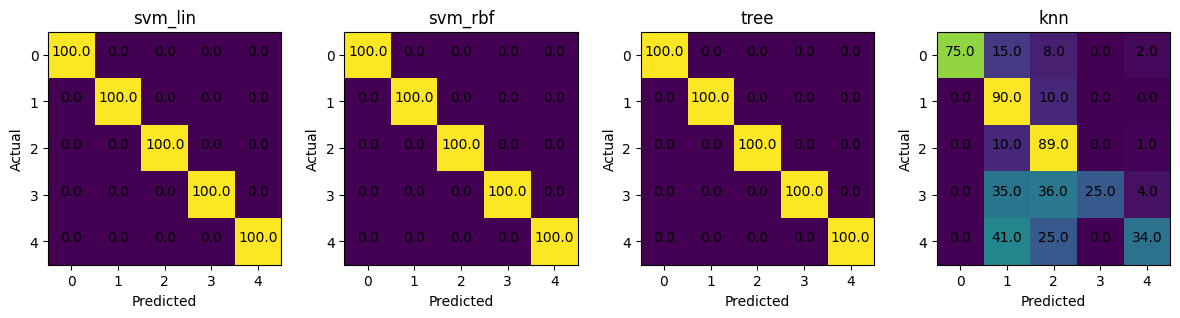

In [334]:
# Plot the confusion matrix of grid search cross validation
plot_confusion_matrix(cm)

### Load and validate the model

In [337]:
# Load the model
data_model = joblib.load(f'{dataset_path}/models/search_grid_cv.pkl')

In [339]:
loaded_models = data_model['models']
trained_mean = data_model['mean']
trained_std = data_model['std']
feature_names = data_model['feature_names']

In [340]:
loaded_models

{'svm_lin': SVC(C=0.1, decision_function_shape='ovo', kernel='linear', probability=True),
 'svm_rbf': SVC(C=10, decision_function_shape='ovo', gamma=0.01),
 'tree': DecisionTreeClassifier(max_depth=20),
 'knn': KNeighborsClassifier(n_neighbors=3)}

In [342]:
trained_mean, trained_std

(np.float64(-7.722436248168051),
 X1       145.116421
 X2       162.989411
 X3       188.014928
 X4       200.960742
 X5       188.664725
             ...    
 X4090    166.025942
 X4091    166.939434
 X4092    177.303081
 X4093    181.496885
 X4094    173.692349
 Length: 4094, dtype: float64)

In [343]:
feature_names

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       ...
       'X4085', 'X4086', 'X4087', 'X4088', 'X4089', 'X4090', 'X4091', 'X4092',
       'X4093', 'X4094'],
      dtype='object', length=4094)

In [369]:
df_sample = df.sample(n=5, random_state=None)
# Scale the sample using z-transform to predict the pre-trained model
sample_test = (df_sample[feature_names]- trained_mean)/trained_std
ground_truth = df_sample['y']
sample_test

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X4085,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094
107,-0.518739,-0.467991,-0.395062,-0.304923,-0.292994,-0.274786,-0.308326,-0.382382,-0.497153,-0.587356,...,-0.388682,-0.385054,-0.376887,-0.413629,-0.441374,-0.465455,-0.462908,-0.480971,-0.519445,-0.571571
241,0.673407,0.710000,0.615496,0.516133,0.443763,0.241073,-0.047461,-0.356579,-0.606520,-0.806140,...,0.005371,0.113211,0.108866,0.036454,-0.030538,-0.061903,-0.031614,0.009715,0.130704,0.228694
450,-0.691015,-0.688864,-0.687592,-0.618417,-0.558014,-0.499337,-0.517017,-0.588804,-0.574353,-0.323528,...,0.473774,0.464552,0.384863,0.426887,0.692765,0.859639,0.830975,0.754203,0.494347,0.435957
15,0.122126,0.010568,-0.033389,-0.031238,-0.006772,0.004384,0.056884,0.075618,0.049681,-0.001786,...,0.042546,0.125987,0.169586,0.237093,0.316647,0.245278,0.190024,0.156356,0.169273,0.171121
138,0.377093,0.311201,0.221910,0.157854,0.131039,0.095418,0.043841,-0.001790,-0.053252,-0.130483,...,0.191245,0.170703,0.114386,0.101526,0.114122,0.082652,0.094180,0.054835,0.048058,0.038703


In [355]:
accuracy, y_pred, y_prob, cm = validate_model(loaded_models['svm_rbf'], X_test=sample_test, y_test=ground_truth)
accuracy

np.float64(1.0)

In [360]:
y_pred, ground_truth.tolist()

(array([4, 2, 1, 5, 1]), [4, 2, 1, 5, 1])

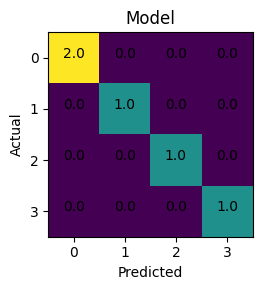

In [362]:
plot_confusion_matrix(cm)

## Classifier models

In [363]:
param_grids = None
random_state = None
include_outlier = True
threshold = None
iteration = 5
accuracy, trained_models, table, cm, trained_mean, trained_std, feature_columns = classifier_models(iteration=iteration,
                                                        random_state=random_state,
                                                        include_outlier=include_outlier,
                                                        threshold=threshold,
                                                        param_grids = param_grids)
print(f'Saving the models\n')
joblib.dump({'models': trained_models,
             'mean': trained_mean,
             'std': trained_std,
             'feature_names': feature_columns
             }, filename=f'{dataset_path}/models/classifier.pkl')
print(f'Saved models successfully\n')
print("----------------- Classifier models accuracy table ---------------")
table

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


Saving the models

Saved models successfully

----------------- Classifier models accuracy table ---------------


,kernal,mean,std,iteration,seed,include_outlier,threshold
0,svm_lin,0.54,0.000000,5,None,True,None
1,svm_rbf,0.55,0.000000,5,None,True,None
2,tree,0.32,0.025298,5,None,True,None
3,knn,0.26,0.000000,5,None,True,None


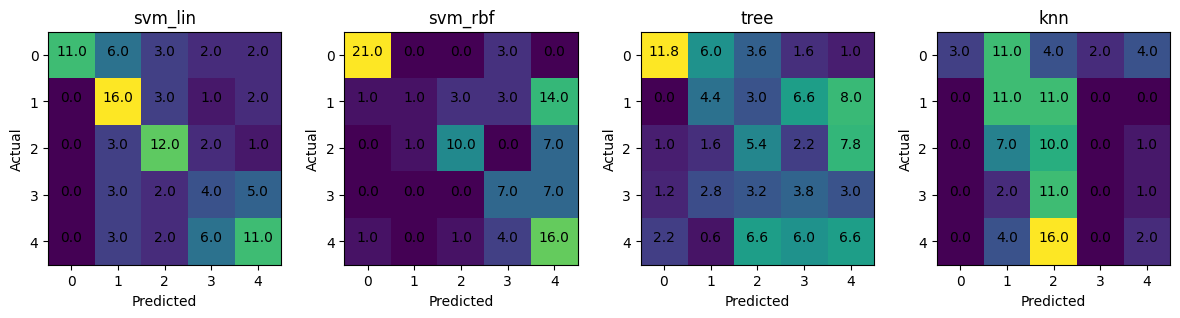

In [364]:
plot_confusion_matrix(cm)

## Validating a model

In [368]:
# Load the model
data_model = joblib.load(f'{dataset_path}/models/classifier.pkl')
loaded_models = data_model['models']
trained_mean = data_model['mean']
trained_std = data_model['std']
feature_names = data_model['feature_names']

# Create a random sample for testing
df_sample = df.sample(n=5, random_state=None)
# Scale the sample using z-transform to predict the pre-trained model
sample_test = (df_sample[feature_names]- trained_mean)/trained_std
ground_truth = df_sample['y']
sample_test

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X4085,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094
54,0.060106,-0.240982,-0.490799,-0.916983,-1.294771,-1.634226,-1.697428,-1.343536,-0.934620,-0.664574,...,-0.671210,-0.365890,0.186145,0.839011,1.404495,1.570372,1.298210,0.844444,0.604542,0.516560
435,-0.153515,-0.161223,-0.134444,0.063308,0.205245,0.423140,0.500354,0.282040,0.056114,-0.136918,...,-0.143328,0.081271,0.246865,0.209979,-0.007393,-0.176343,-0.241271,-0.057966,0.026019,0.061732
47,0.032542,0.035109,0.009161,-0.041190,-0.091578,-0.189821,-0.308326,-0.375931,-0.419953,-0.484399,...,-0.187938,-0.084817,-0.034652,0.068990,0.119909,0.173000,0.184033,0.280438,0.290487,0.366870
399,-0.821944,-0.958820,-0.937572,-1.001577,-1.141059,-1.537123,-1.951771,-2.601422,-2.806723,-2.028759,...,1.812066,0.656193,0.015028,-0.310598,-0.476093,-0.417270,-0.229290,-0.007206,0.268448,0.752609
224,0.487350,0.378690,0.317647,0.262352,0.300652,0.326038,0.285141,0.191730,0.120448,0.068997,...,0.696822,0.566760,0.451102,0.443155,0.524959,0.588597,0.633298,0.630121,0.637600,0.625948


In [370]:
accuracy, y_pred, y_prob, cm = validate_model(loaded_models['svm_rbf'], X_test=sample_test, y_test=ground_truth)
accuracy

np.float64(0.8)

In [372]:
y_pred, ground_truth.tolist()

(array([3, 4, 3, 5, 3]), [3, 4, 3, 5, 2])

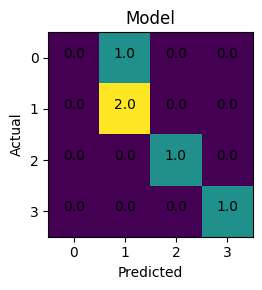

In [373]:
plot_confusion_matrix(cm)